In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [16]:
df = pd.read_csv("df_assignment.csv.gz", )


focus_crime = [
    "larceny theft",
    "motor vehicle theft",
    "robbery",
    "assault",
    "drug offense",
    "weapons offense",
    "vandalism",
    "suicide",
]


df.loc[df["category"] == "malicious mischief", "category"] = "vandalism"

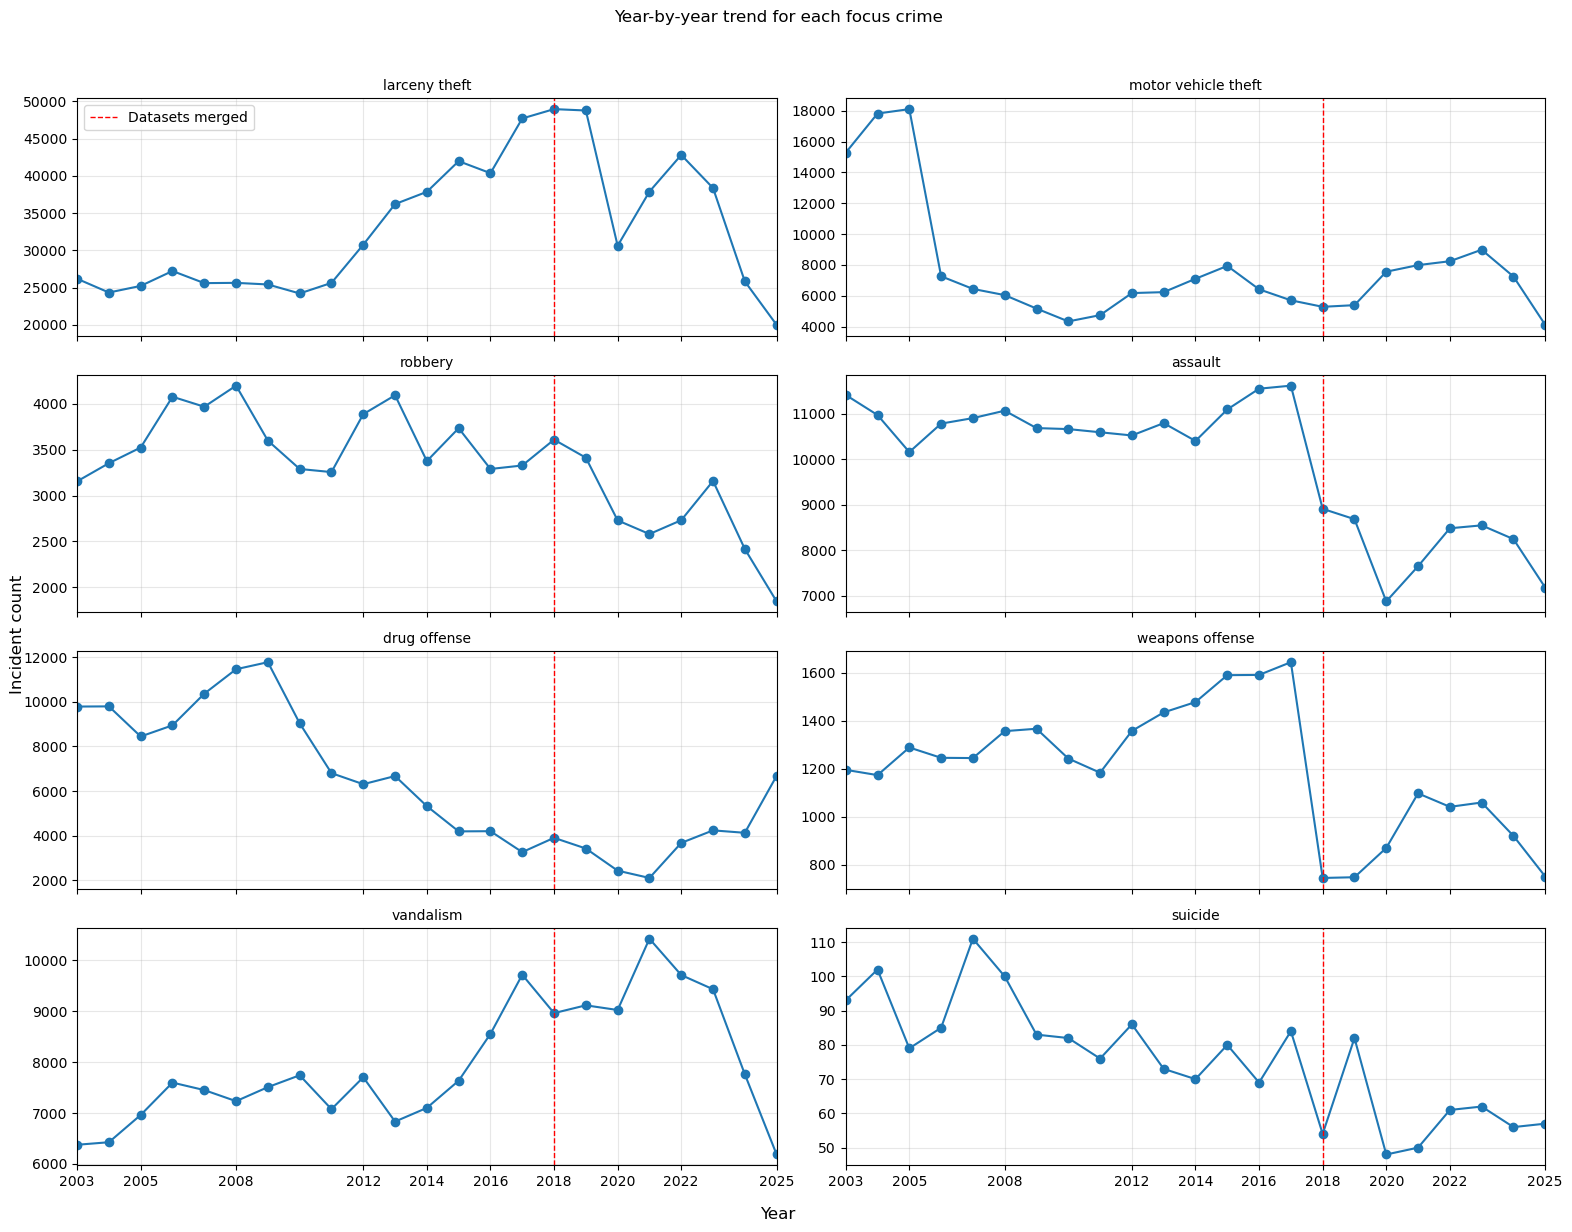

In [17]:

counts = (
    df[df["category"].isin(focus_crime)]
    .groupby(["year", "category"])
    .size()
    .unstack("category", fill_value=0)
    .sort_index()
)

years_to_label = [2003, 2005, 2008, 2012, 2014, 2016, 2018, 2020, 2022, 2025]

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
axes = np.array(axes).reshape(4, 2)

for idx, crime in enumerate(focus_crime):
    r, c = divmod(idx, 2)
    ax = axes[r, c]

    # .get avoids KeyError if a category is missing in counts for some reason
    y = counts.get(crime, 0)

    ax.plot(counts.index, y.values, marker="o", linewidth=1.5)
    ax.set_title(crime, fontsize=10)
    ax.grid(True, alpha=0.3)

    ax.axvline(2018, linestyle="--", linewidth=1, label="Datasets merged",color="red")


    ax.set_xticks(years_to_label)
    ax.set_xlim(min(years_to_label), max(years_to_label))

# Hide unused axes if focus_crime has fewer than 8 items
for j in range(len(focus_crime), axes.size):
    axes.flat[j].set_visible(False)

axes[0, 0].legend(loc="upper left")
fig.supxlabel("Year")
fig.supylabel("Incident count")
fig.suptitle("Year-by-year trend for each focus crime", y=1.02)

plt.tight_layout()
plt.show()